## 모듈 불러오기

In [4]:
# import sys
# !{sys.executable} - m pip install catboost optuna shap

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy as stats
import seaborn as sns
import numpy as np
import platform
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, recall_score,precision_score, f1_score, ConfusionMatrixDisplay
from catboost import CatBoostClassifier
import optuna
import shap

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [6]:
# 데이터 불러오기
df = pd.read_csv('./data/Courses.csv', parse_dates=['start_time_DI', 'last_event_DI'])
df.head()

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaT,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0


In [7]:
# 전처리용 데이터프레임 생성
pre = df.copy()

In [8]:
# 파생컬럼 생성

# 학생들의 나이(age) & (age_segment)
pre['age'] = pre['start_time_DI'].dt.year - pre['YoB']

conditions = [
    pre['age'] >= 60,
    pre['age'] >= 50,
    pre['age'] >= 40,
    pre['age'] >= 30,
    pre['age'] >= 20,
]

choices = ['60s+', '50s', '40s', '30s', '20s']

pre['age_segment'] = np.select(conditions, choices, default='under 20')

# 퍼널 단계 컬럼(step): 각 학생 별 진행 단계
pre['step'] = np.select(
    [
        pre['certified'] ==1,
        pre['explored'] == 1,
        pre['viewed'] == 1,
        pre['registered'] == 1,
    ],
    [
        'Certified',
        'Explored',
        'Viewed',
        'Registered'
    ],
    default='None'
)

# Missing Flag 컬럼 생성
missing_col = [
    'nchapters', 
    'nevents', 
    'ndays_act', 
    'nplay_video', 
    'last_event_DI', 
    'age', 
    'grade']

for col in missing_col:
    pre[f'{col}_flag'] = pre[col].isna().astype(int)
    

# 학습 기간 (duration) 컬럼 생성
pre['duration'] = (pre['last_event_DI'] - pre['start_time_DI']).dt.days.astype(int, errors='ignore')

In [9]:
# 결측치 대체

# 성별 결측치(gender) : unknown 대체
pre['gender'] = pre['gender'].fillna('unknown')

# 학력 결측치(LoE_DI) : unknown 대체
pre['LoE_DI'] = pre['LoE_DI'].fillna('unknown')

# 탐색한 챕터 수 결측치(nchapters) : registered 단계일 때 0으로 대체
pre['nchapters'] = pre[pre['step']=='Registered']['nchapters'].fillna(0)

# 총 이벤트 발생 수 결측치(nevent) : registered 단계일 때 0으로 대체
pre['nevents'] = pre[pre['step']=='Registered']['nevents'].fillna(0)

# 활성 일수 결측치(ndays_act) : 0으로 대체
pre['ndays_act'] = pre['ndays_act'].fillna(0)

# 영상재생횟수(nplay_video) 결측치 : 논의중

# 마지막 이벤트 발생일 (last_event_DI) : 논의중

# 나이 (age) 결측치 : 논의중

# 성적(grade) 결측치 : 논의중




In [10]:
# 행제거
print('행 제거 작업 시작 전:')
print(pre.shape)

# 퍼널 논리적 오류 행 제거
funnel_mask1 = (pre['viewed'] == 0) & (pre['explored'] == 1)
funnel_mask2 = (pre['explored'] == 0) & (pre['certified'] == 1)
pre = pre[~funnel_mask1]
pre = pre[~funnel_mask2]

# durration 음수 행 제거
duration_mask = pre['duration'] < 0
pre = pre[~duration_mask]

# age 13세 미만 행 제거
age_mask = pre['age'] < 13
pre = pre[~age_mask]

# nchapters가 0인 viewed, explored, certified 행 제거
nchapter_mask = (pre['step'].isin(['Certified', 'Viewed', 'Explored'])) & (pre['nchapters']==0)
pre = pre[~nchapter_mask]

# 상시 개방된 강의 제거 
course_mask = (pre['course_id'] =='HarvardX/CS50x/2012') | (pre['course_id'] =='HarvardX/ER22x/2013_Spring') | (pre['course_id'] =='HarvardX/CB22x/2013_Spring')
pre = pre[~course_mask]

# incomplete_flag == 1 제외
pre = pre[pre['incomplete_flag'].isna()]

print('행 제거 작업 시작 후:')
print(pre.shape)

행 제거 작업 시작 전:
(641138, 32)


C:\Users\my100\AppData\Local\Temp\ipykernel_11468\2960777977.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre = pre[~funnel_mask2]


행 제거 작업 시작 후:
(355438, 32)


In [11]:
pre.isna().sum()

index                      0
course_id                  0
userid_DI                  0
registered                 0
viewed                     0
explored                   0
certified                  0
final_cc_cname_DI          0
LoE_DI                     0
YoB                    58978
gender                     0
grade                  31397
start_time_DI              0
last_event_DI          29858
nevents               235209
ndays_act                  0
nplay_video           174389
nchapters             235209
nforum_posts               0
roles                 355438
incomplete_flag       355438
age                    58978
age_segment                0
step                       0
nchapters_flag             0
nevents_flag               0
ndays_act_flag             0
nplay_video_flag           0
last_event_DI_flag         0
age_flag                   0
grade_flag                 0
duration               29858
dtype: int64

In [12]:
# 컬럼 제거
pre = pre.drop(columns=['index', 'roles', 'YoB', 'registered', 'viewed', 'explored', 'start_time_DI', 'last_event_DI', 'userid_DI', 'age', 'step','grade', 'incomplete_flag', 'nplay_video', 'nchapters', 'nevents', 'duration'])

In [13]:
# 결측치 개수, 비율
display(pd.DataFrame({
    'bf_sum': df.isna().sum(),
    'bf_ratio': df.isna().mean() * 100,
    'af_sum': pre.isna().sum(),
    'af_ratio': pre.isna().mean() * 100
}).sort_values('bf_ratio', ascending=False).reset_index())

,index,bf_sum,bf_ratio,af_sum,af_ratio
0,roles,641138.0,100.000000,NaN,NaN
1,incomplete_flag,540977.0,84.377622,NaN,NaN
2,nplay_video,457530.0,71.362172,NaN,NaN
3,nchapters,258753.0,40.358394,NaN,NaN
4,nevents,199151.0,31.062111,NaN,NaN
5,last_event_DI,178954.0,27.911932,NaN,NaN
6,ndays_act,162743.0,25.383459,0.0,0.0
7,LoE_DI,106008.0,16.534350,0.0,0.0
8,YoB,96605.0,15.067739,NaN,NaN
9,gender,86806.0,13.539363,0.0,0.0


In [14]:
# 머러 시작
# test, train 분리
y = pre['certified'].astype(int)
X = pre.drop(columns=['certified']).copy()

# 범주형 컬럼
cat_cols = X.select_dtypes(exclude='number').columns.tolist()
cat_idx = [X.columns.get_loc(c) for c in cat_cols]
num_cols = X.select_dtypes(include='number').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42, stratify=y
)

In [15]:
# 1. train / valid 분리

# Optuna 내부 평가용 validation set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

cat_idx_tr = [X_tr.columns.get_loc(col) for col in cat_cols]

# 2. Optuna objective 함수

def objective(trial):
    params = {
        "loss_function": "Logloss",
        "eval_metric": "PRAUC",   # CatBoost 내부 평가도 PR-AUC 기준
        "random_seed": 42,
        "verbose": 0,
        "auto_class_weights": "Balanced",

        # 튜닝 대상
        "iterations": trial.suggest_int("iterations", 500, 1200),
        "depth": trial.suggest_int("depth", 8, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    }

    model = CatBoostClassifier(**params)

    model.fit(
        X_tr, y_tr,
        cat_features=cat_idx_tr,
        eval_set=(X_val, y_val),
        use_best_model=True,
        early_stopping_rounds=100
    )

    y_val_proba = model.predict_proba(X_val)[:, 1]

    # sklearn PR-AUC
    pr_auc = average_precision_score(y_val, y_val_proba)

    return pr_auc


# 3. Optuna 실행

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\n=== Best Trial ===")
print("Best PR-AUC:", study.best_value)
print("Best Params:")
print(study.best_params)


# 4. 최적 파라미터로 전체 train 학습

best_params = study.best_params.copy()

final_model = CatBoostClassifier(
    **best_params,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=42,
    verbose=100,
    auto_class_weights="Balanced"
)

final_model.fit(
    X_train, y_train,
    cat_features=cat_idx,
    eval_set=(X_test, y_test),   # 최종 확인용
    use_best_model=True
)


# 5. 테스트 평가

y_pred = final_model.predict(X_test)
y_pred = np.array(y_pred).astype(int).ravel()

y_proba = final_model.predict_proba(X_test)[:, 1]

print("\n=== Test Performance ===")
print(f"PR-AUC   : {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

[I 2026-03-24 00:44:55,889] A new study created in memory with name: no-name-e2864c1d-69dc-41be-9eaa-5b4ff598b42f
Best trial: 0. Best value: 0.842131:   3%|▎         | 1/30 [00:42<20:22, 42.15s/it]

[I 2026-03-24 00:45:38,039] Trial 0 finished with value: 0.8421311682095357 and parameters: {'iterations': 1112, 'depth': 8, 'learning_rate': 0.05131301112477809, 'l2_leaf_reg': 2.289939788276337, 'min_data_in_leaf': 45, 'subsample': 0.8622623505769853}. Best is trial 0 with value: 0.8421311682095357.


Best trial: 1. Best value: 0.844132:   7%|▋         | 2/30 [02:06<31:16, 67.01s/it]

[I 2026-03-24 00:47:02,446] Trial 1 finished with value: 0.8441318946782007 and parameters: {'iterations': 1099, 'depth': 11, 'learning_rate': 0.05008353952746093, 'l2_leaf_reg': 1.837746569430121, 'min_data_in_leaf': 5, 'subsample': 0.6868529832788932}. Best is trial 1 with value: 0.8441318946782007.


Best trial: 1. Best value: 0.844132:  10%|█         | 3/30 [03:25<32:37, 72.51s/it]

...

[I 2026-03-24 01:24:45,816] Trial 27 finished with value: 0.8426359880492181 and parameters: {'iterations': 925, 'depth': 9, 'learning_rate': 0.091404944920032, 'l2_leaf_reg': 1.94788970687885, 'min_data_in_leaf': 7, 'subsample': 0.6285064879894298}. Best is trial 17 with value: 0.8455863011874423.


Best trial: 17. Best value: 0.845586:  97%|█████████▋| 29/30 [41:44<01:22, 82.54s/it]

[I 2026-03-24 01:26:40,038] Trial 28 finished with value: 0.8424381821591689 and parameters: {'iterations': 828, 'depth': 9, 'learning_rate': 0.016506903412079933, 'l2_leaf_reg': 2.14705752221545, 'min_data_in_leaf': 1, 'subsample': 0.7246434665189241}. Best is trial 17 with value: 0.8455863011874423.


Best trial: 17. Best value: 0.845586: 100%|██████████| 30/30 [43:14<00:00, 86.47s/it]


[I 2026-03-24 01:28:10,076] Trial 29 finished with value: 0.8430343271435855 and parameters: {'iterations': 1041, 'depth': 10, 'learning_rate': 0.05355212432295379, 'l2_leaf_reg': 2.4442103127508057, 'min_data_in_leaf': 20, 'subsample': 0.8548095283583479}. Best is trial 17 with value: 0.8455863011874423.

=== Best Trial ===
Best PR-AUC: 0.8455863011874423
Best Params:
{'iterations': 1099, 'depth': 9, 'learning_rate': 0.03010943037747427, 'l2_leaf_reg': 1.7499300467648662, 'min_data_in_leaf': 33, 'subsample': 0.6762189548565792}
0:	learn: 0.9802797	test: 0.9788642	best: 0.9788642 (0)	total: 174ms	remaining: 3m 10s
100:	learn: 0.9909461	test: 0.9895940	best: 0.9895940 (100)	total: 18.4s	remaining: 3m 1s
200:	learn: 0.9916710	test: 0.9901759	best: 0.9901759 (199)	total: 34.2s	remaining: 2m 32s
300:	learn: 0.9919623	test: 0.9903404	best: 0.9903411 (299)	total: 48.8s	remaining: 2m 9s
400:	learn: 0.9922193	test: 0.9904244	best: 0.9904244 (400)	total: 1m 3s	remaining: 1m 50s
500:	learn: 0.99

In [16]:
#{'iterations': 1000, 'depth': 12, 'learning_rate': 0.03688485345853623, 'l2_leaf_reg': 1.0596783600864867, 'min_data_in_leaf': 8, 'subsample': 0.7694568297709484}
# 6. 최적 파라미터로 전체 train 학습

# best_params = study.best_params.copy()

final_model = CatBoostClassifier(
    # **best_param,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=42,
    verbose=100,
    auto_class_weights="Balanced",
    max_depth=7,
    iterations=358,
    learning_rate=0.05459690286945743,
    l2_leaf_reg=1.5080143762878997,
    min_data_in_leaf=14,
    subsample=0.9672172477416252
)

final_model.fit(
    X_train, y_train,
    cat_features=cat_idx,
    eval_set=(X_test, y_test),   # 최종 확인용
    use_best_model=True
)


# 7. 테스트 평가

y_pred = final_model.predict(X_test)
y_pred = np.array(y_pred).astype(int).ravel()

y_proba = final_model.predict_proba(X_test)[:, 1]

print("\n=== Test 데이터 모델 성능 ===")
print(f"PR-AUC   : {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

0:	learn: 0.9802797	test: 0.9788642	best: 0.9788642 (0)	total: 161ms	remaining: 57.6s
100:	learn: 0.9912633	test: 0.9900639	best: 0.9900639 (100)	total: 15.6s	remaining: 39.8s
200:	learn: 0.9916916	test: 0.9903186	best: 0.9903186 (200)	total: 29.2s	remaining: 22.8s
300:	learn: 0.9919322	test: 0.9904162	best: 0.9904183 (274)	total: 42.9s	remaining: 8.12s
357:	learn: 0.9920609	test: 0.9904698	best: 0.9904698 (357)	total: 50.8s	remaining: 0us

bestTest = 0.9904697865
bestIteration = 357


=== Test 데이터 모델 성능 ===
PR-AUC   : 0.8308
ROC-AUC  : 0.9927
Recall   : 0.9780
Precision: 0.4763
F1-score : 0.6406

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9991    0.9578    0.9780     68403
           1     0.4763    0.9780    0.6406      2685

    accuracy                         0.9586     71088
   macro avg     0.7377    0.9679    0.8093     71088
weighted avg     0.9794    0.9586    0.9653     71088


=== Confusion Matrix ===
[[65516  288

In [17]:
# 1 클래스일 확률
y_proba = final_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.001)

results = []
best_f1 = 0
best_threshold = 0.5

for th in thresholds:
    y_pred_th = (y_proba >= th).astype(int)

    precision = precision_score(y_test, y_pred_th, zero_division=0)
    recall = recall_score(y_test, y_pred_th, zero_division=0)
    f1 = f1_score(y_test, y_pred_th, zero_division=0)

    results.append({
        "threshold": th,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

result_df = pd.DataFrame(results)

print("최적 threshold:", best_threshold)
print("최적 F1:", best_f1)

display(result_df.sort_values("f1", ascending=False).head(10))

최적 threshold: 0.9390000000000008
최적 F1: 0.7762784090909091


,threshold,precision,recall,f1
889,0.939,0.741771,0.814153,0.776278
887,0.937,0.737106,0.819739,0.776230
890,0.940,0.743520,0.811918,0.776215
888,0.938,0.740365,0.815642,0.776183
892,0.942,0.746299,0.807449,0.775671
893,0.943,0.747067,0.806331,0.775569
891,0.941,0.745024,0.808566,0.775496
885,0.935,0.731942,0.822719,0.774680
886,0.936,0.733511,0.820112,0.774398
884,0.934,0.729400,0.824209,0.773912


In [18]:
# 적용 후 성능 확인

best_threshold = 0.934
y_pred_opt = (y_proba >= best_threshold).astype(int)


print("=== 최적 threshold 적용 후 성능 ===")
print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC    : {average_precision_score(y_test, y_proba):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_opt):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_opt):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_opt, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_opt))

=== 최적 threshold 적용 후 성능 ===
Threshold : 0.93
Accuracy  : 0.9818
ROC-AUC   : 0.9927
PR-AUC    : 0.8308
Precision : 0.7294
Recall    : 0.8242
F1-score  : 0.7739

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9931    0.9880    0.9905     68403
           1     0.7294    0.8242    0.7739      2685

    accuracy                         0.9818     71088
   macro avg     0.8612    0.9061    0.8822     71088
weighted avg     0.9831    0.9818    0.9823     71088


=== Confusion Matrix ===
[[67582   821]
 [  472  2213]]


<Figure size 1200x700 with 0 Axes>

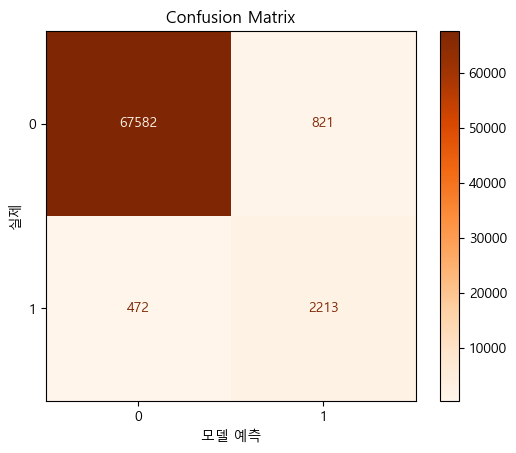

In [19]:
# 혼동행렬 출력
plt.figure(figsize=(12,7))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt, cmap='Oranges', values_format="d")
plt.title("Confusion Matrix")
plt.xlabel('모델 예측')
plt.ylabel('실제')
plt.show()

In [20]:
# shap

# shap explainer 생성
explainer = shap.TreeExplainer(final_model)

# test 데이터에 대한 shap value 계산
shap_values = explainer.shap_values(X_test)

# 이진분류일 때
# 어떤 환경에서는 list가 아니라 바로 array로 나올 수도 있음
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# shop
print(np.array(shap_values_class1).shape)

(71088, 14)


c:\Users\my100\OneDrive\Desktop\내일배움캠프\실전프로젝트\HOHO_Project\.venv\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\my100\OneDrive\Desktop\내일배움캠프\실전프로젝트\HOHO_Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


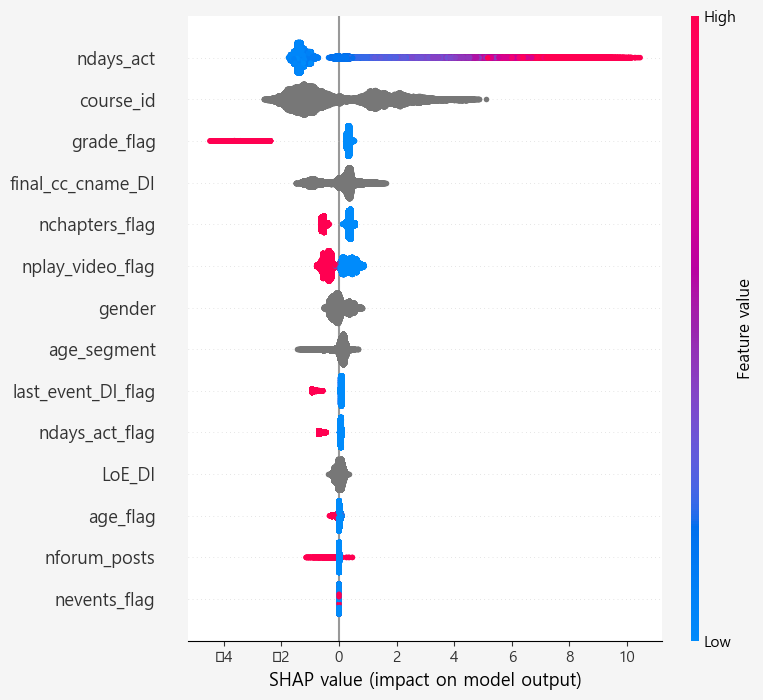

In [21]:
plt.figure(facecolor='whitesmoke')
shap.summary_plot(shap_values_class1, X_test)

In [22]:
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values_class1).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

display(shap_importance.head(20))

,feature,mean_abs_shap
4,ndays_act,1.828835
0,course_id,1.379693
13,grade_flag,0.586876
1,final_cc_cname_DI,0.460747
7,nchapters_flag,0.428375
10,nplay_video_flag,0.376669
3,gender,0.208168
6,age_segment,0.163336
11,last_event_DI_flag,0.143519
9,ndays_act_flag,0.108952
